# ResNet50 AI-Image Detector — Production-Grade Student Notebook
### Kaggle T4 × 2 | Binary: AI-generated vs Real Images

**Every technique in this notebook exists to prevent wasted training time:**

| Technique | Why it matters |
|-----------|---------------|
| SSD data copy | 10× faster I/O than /kaggle/input |
| Dedup-aware split (cached) | No leakage, no re-hashing |
| LR Range Test | Find best LR in 2 min instead of guessing |
| Sanity overfit check | Catch bugs before full training |
| Warmup + OneCycleLR | Fastest convergence, no manual LR tuning |
| Differential LR (Phase 2) | Prevents catastrophic forgetting |
| Early stopping + patience | Never train past peak val performance |
| Gradient clipping | Prevents exploding gradients |
| Label smoothing | Reduces overconfident wrong predictions |
| Test-Time Augmentation (TTA) | Free +0.5–1% accuracy at inference |
| Optimal threshold (Youden J) | Better than hard-coded 0.5 cutoff |
| Calibration plot | Know if model confidence is trustworthy |
| Per-class metrics + error analysis | Understand *where* it fails |
| Model export (ONNX + .ptl) | Ready for deployment |


In [1]:
# ═══════════════════════════════════════════════════════════
# Cell 1 · Environment detection
# ═══════════════════════════════════════════════════════════
import os, sys, time

ON_KAGGLE = os.path.isdir('/kaggle/input')
try:
    import google.colab; ON_COLAB = True
except ImportError:
    ON_COLAB = False

env = "Kaggle" if ON_KAGGLE else ("Colab" if ON_COLAB else "Local")
print(f"[ENV] Platform : {env}")

if ON_KAGGLE:
    print(f"[ENV] Inputs   : {os.listdir('/kaggle/input')}")
elif ON_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("[ENV] Drive mounted")


[ENV] Platform : Kaggle
[ENV] Inputs   : ['datasets']


In [2]:
# ═══════════════════════════════════════════════════════════
# Cell 2 · Dependencies
# ═══════════════════════════════════════════════════════════
import subprocess

def pip(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *pkgs], check=True)

if not ON_KAGGLE:
    pip('torch', 'torchvision', 'torchaudio')
pip('scikit-learn', 'matplotlib', 'seaborn', 'tqdm')
print("[DEPS] All packages ready")


[DEPS] All packages ready


In [3]:
# ═══════════════════════════════════════════════════════════
# Cell 3 · Imports & device
# ═══════════════════════════════════════════════════════════
import os, shutil, random, time, hashlib, warnings, pickle, math
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, brier_score_loss)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')

print(f"[IMPORTS] PyTorch {torch.__version__}")

# ── Device ──────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    device = torch.device('cuda:0')
    torch.backends.cudnn.benchmark   = True
    torch.backends.cudnn.deterministic = False
    n_gpus = torch.cuda.device_count()
    for i in range(n_gpus):
        p = torch.cuda.get_device_properties(i)
        print(f"[GPU {i}] {p.name}  {p.total_memory/1024**3:.1f} GB")
else:
    device, n_gpus = torch.device('cpu'), 0
    print("[DEVICE] CPU only")

USE_AMP = (device.type == 'cuda')
print(f"[DEVICE] Primary={device}  GPUs={n_gpus}  AMP={USE_AMP}")


[IMPORTS] PyTorch 2.10.0+cu128
[GPU 0] Tesla T4  14.6 GB
[GPU 1] Tesla T4  14.6 GB
[DEVICE] Primary=cuda:0  GPUs=2  AMP=True


In [4]:
# ═══════════════════════════════════════════════════════════
# Cell 4 · Paths & hyper-parameters
# ═══════════════════════════════════════════════════════════
# ── Paths ────────────────────────────────────────────────
REMOTE_DATA = "/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images"
LOCAL_DATA  = "/kaggle/working/local_data"   # NVMe SSD
OUTPUT_DIR  = "/kaggle/working/output"
CACHE_PATH  = "/kaggle/working/dedup_cache.pkl"
BEST_CKPT   = f"{OUTPUT_DIR}/best.pth"
LAST_CKPT   = f"{OUTPUT_DIR}/last.pth"

for d in [OUTPUT_DIR, LOCAL_DATA]: os.makedirs(d, exist_ok=True)

# ── Seed ─────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ── Data ─────────────────────────────────────────────────
BATCH_SIZE  = 128
NUM_WORKERS = 4        # optimal for Kaggle 4 vCPUs
VAL_RATIO   = 0.15
IMG_SIZE    = 224

# ── FAST MODE: Limit training set size ──────────────────
# Set to None to use all data, or specify max images (e.g., 20000)
MAX_TRAIN_IMAGES = None  # ← CHANGE THIS: None for all data, or 20000, 30000, etc
FAST_MODE = (MAX_TRAIN_IMAGES is not None)

# ── ImageNet stats ────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ── Phase 1 — head only (FAST) ──────────────────────────
PHASE1_EPOCHS = 3 if FAST_MODE else 5   # Reduced for speed
PHASE1_LR     = 3e-4

# ── Phase 2 — full fine-tune (FAST) ─────────────────────
PHASE2_EPOCHS   = 3 if FAST_MODE else 5   # Reduced for speed
PHASE2_LR       = 5e-5
WEIGHT_DECAY    = 1e-4
LABEL_SMOOTHING = 0.05
GRAD_CLIP       = 1.0

# ── Early stopping ────────────────────────────────────────
ES_PATIENCE_P1 = 2 if FAST_MODE else 3
ES_PATIENCE_P2 = 2 if FAST_MODE else 4
ES_MIN_DELTA   = 1e-4

print("[CONFIG] Dataset  :", REMOTE_DATA)
print(f"[CONFIG] Batch={BATCH_SIZE}  Workers={NUM_WORKERS}  Val={VAL_RATIO}")
if FAST_MODE:
    print(f"[CONFIG] ⚡ FAST MODE: max {MAX_TRAIN_IMAGES:,} images for training")
    print(f"[CONFIG] Phase1: {PHASE1_EPOCHS}ep  Phase2: {PHASE2_EPOCHS}ep")
else:
    print(f"[CONFIG] Phase1: {PHASE1_EPOCHS}ep  Phase2: {PHASE2_EPOCHS}ep (full data)")
print(f"[CONFIG] Label smoothing={LABEL_SMOOTHING}  GradClip={GRAD_CLIP}")


[CONFIG] Dataset  : /kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images
[CONFIG] Batch=128  Workers=4  Val=0.15
[CONFIG] Phase1: 5ep  Phase2: 5ep (full data)
[CONFIG] Label smoothing=0.05  GradClip=1.0


In [5]:
# ═══════════════════════════════════════════════════════════
# Cell 5 · Smart dataset loading
# ───────────────────────────────────────────────────────────
# WARNING: 60k images ≈ 33 GB  but Kaggle RAM limit ≈ 24 GB usable
# Strategy:
#   1. Check available disk space
#   2. If ~30+ GB free → copy to SSD (10× faster I/O)
#   3. If <20 GB free  → read directly from /kaggle/input (slower)
# ═══════════════════════════════════════════════════════════
import shutil as _shutil_mod
SENTINEL  = os.path.join(LOCAL_DATA, '.done')
VALID_EXT = {'.jpg','.jpeg','.png','.webp','.bmp'}

# ─ Check available space ──────────────────────────────────
def _get_free_space_mb(path):
    stat = os.statvfs(path)
    return (stat.f_bavail * stat.f_frsize) / (1024**2)

def _count_total_size_mb(root_path):
    total = 0
    for root, dirs, files in os.walk(root_path):
        for f in files:
            if Path(f).suffix.lower() in VALID_EXT:
                total += os.path.getsize(os.path.join(root, f)) / (1024**2)
    return total

print("[MEMORY] Checking dataset size …")
remote_size_mb = _count_total_size_mb(REMOTE_DATA)
free_mb = _get_free_space_mb(LOCAL_DATA)
print(f"[MEMORY] Dataset total    : {remote_size_mb:,.0f} MB  ({remote_size_mb/1024:.1f} GB)")
print(f"[MEMORY] Free space       : {free_mb:,.0f} MB  ({free_mb/1024:.1f} GB)")

SHOULD_COPY = (free_mb > remote_size_mb * 1.2)  # 20% safety margin
USE_LOCAL_DATA = SHOULD_COPY

if SHOULD_COPY:
    print("[MEMORY] ✓ Enough space — copying to fast SSD")
else:
    print("[MEMORY] ⚠ Limited space — reading directly from /kaggle/input (slower)")
    LOCAL_DATA = REMOTE_DATA  # read directly, don't copy

# ─ Copy if needed ────────────────────────────────────────
def _copy_split(split):
    src = Path(REMOTE_DATA) / split
    dst = Path(LOCAL_DATA)  / split
    if not src.exists():
        print(f"[COPY] {split} not found — skip"); return 0
    total = 0
    for cls_dir in sorted(src.iterdir()):
        if not cls_dir.is_dir(): continue
        (dst / cls_dir.name).mkdir(parents=True, exist_ok=True)
        files = [f for f in cls_dir.iterdir() if f.suffix.lower() in VALID_EXT]
        already = len(list((dst / cls_dir.name).iterdir()))
        if already >= len(files):
            total += already; continue
        for f in tqdm(files, desc=f"  {split}/{cls_dir.name}", leave=False):
            t = dst / cls_dir.name / f.name
            if not t.exists(): shutil.copy2(f, t)
        total += len(files)
        print(f"[COPY]   {split}/{cls_dir.name}: {len(files):,} imgs")
    return total

if SHOULD_COPY:
    if os.path.exists(SENTINEL):
        print(f"[COPY] SSD data ready (sentinel exists) — skipping copy")
    else:
        print("[COPY] Copying to SSD …")
        t0 = time.time()
        _copy_split('train'); _copy_split('test')
        Path(SENTINEL).touch()
        print(f"[COPY] Done in {time.time()-t0:.0f}s")
else:
    print("[COPY] Skipped — reading directly from /kaggle/input")

train_path  = Path(LOCAL_DATA) / 'train'
CLASS_NAMES = sorted(d.name for d in train_path.iterdir() if d.is_dir())
print(f"[DATA] Classes: {CLASS_NAMES}")
for c in CLASS_NAMES:
    n = len(list((train_path/c).glob('*')))
    print(f"[DATA]   {c}: {n:,}")
print(f"[DATA] Using path: {LOCAL_DATA}")


[MEMORY] Checking dataset size …
[MEMORY] Dataset total    : 49,977 MB  (48.8 GB)
[MEMORY] Free space       : 19,970 MB  (19.5 GB)
[MEMORY] ⚠ Limited space — reading directly from /kaggle/input (slower)
[COPY] Skipped — reading directly from /kaggle/input
[DATA] Classes: ['fake', 'real']
[DATA]   fake: 24,000
[DATA]   real: 24,000
[DATA] Using path: /kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images


In [6]:
# ═══════════════════════════════════════════════════════════
# Cell 6 · Transforms
# Train: moderate augmentation — enough to regularise without
#        destroying AI-artifact signals (compression, GAN seams).
# Eval:  deterministic — no augmentation leaks into metrics.
# TTA:   used at test time for free accuracy boost (Cell 17).
# ═══════════════════════════════════════════════════════════
train_transform = transforms.Compose([
    transforms.Resize((232, 232)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15,
                           saturation=0.10, hue=0.02),
    transforms.RandomGrayscale(p=0.02),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# TTA transforms — 5 deterministic crops (center + 4 corners)
# averaged at inference for free accuracy gain
tta_transforms = [
    transforms.Compose([transforms.Resize((232,232)),
                        transforms.CenterCrop(IMG_SIZE),
                        transforms.ToTensor(), transforms.Normalize(MEAN, STD)]),
    transforms.Compose([transforms.Resize((232,232)),
                        transforms.RandomHorizontalFlip(p=1.0),
                        transforms.CenterCrop(IMG_SIZE),
                        transforms.ToTensor(), transforms.Normalize(MEAN, STD)]),
    transforms.Compose([transforms.Resize((232,232)),
                        transforms.RandomCrop(IMG_SIZE),
                        transforms.ToTensor(), transforms.Normalize(MEAN, STD)]),
    transforms.Compose([transforms.Resize((232,232)),
                        transforms.RandomCrop(IMG_SIZE),
                        transforms.ToTensor(), transforms.Normalize(MEAN, STD)]),
    transforms.Compose([transforms.Resize((232,232)),
                        transforms.RandomCrop(IMG_SIZE),
                        transforms.ToTensor(), transforms.Normalize(MEAN, STD)]),
]

print("[TRANSFORMS] Train  :", [type(t).__name__ for t in train_transform.transforms])
print("[TRANSFORMS] Eval   :", [type(t).__name__ for t in eval_transform.transforms])
print(f"[TRANSFORMS] TTA    : {len(tta_transforms)} views per image")


[TRANSFORMS] Train  : ['Resize', 'RandomCrop', 'RandomHorizontalFlip', 'ColorJitter', 'RandomGrayscale', 'ToTensor', 'Normalize']
[TRANSFORMS] Eval   : ['Resize', 'ToTensor', 'Normalize']
[TRANSFORMS] TTA    : 5 views per image


In [7]:
# ═══════════════════════════════════════════════════════════
# Cell 7 · Dataset + dedup-aware train/val split
# ═══════════════════════════════════════════════════════════
class SafeImageFolder(ImageFolder):
    """Returns black tensor for corrupted images — never crashes DataLoader."""
    _warned = set()
    def __getitem__(self, idx):
        path, target = self.samples[idx]
        try:
            img = self.loader(path)
            if self.transform: img = self.transform(img)
            return img, target
        except Exception as e:
            if path not in self._warned:
                self._warned.add(path)
                print(f"[WARN] Corrupted: {Path(path).name}")
            return torch.zeros(3, IMG_SIZE, IMG_SIZE), target


def _md5(path):
    h = hashlib.md5()
    with open(path,'rb') as f:
        for chunk in iter(lambda: f.read(65536), b''): h.update(chunk)
    return h.hexdigest()


def dedup_split(ds, val_ratio=0.15, seed=42, cache=CACHE_PATH):
    """MD5-based split: duplicates never cross train/val boundary."""
    key = f"{ds.root}|{seed}|{val_ratio}|{len(ds.samples)}"
    if os.path.exists(cache):
        saved = pickle.load(open(cache,'rb'))
        if saved.get('key') == key:
            print(f"[DEDUP] Cache hit → {len(saved['tr']):,} train / {len(saved['va']):,} val")
            return saved['tr'], saved['va']
        print("[DEDUP] Dataset changed — rebuilding split")

    print(f"[DEDUP] Building split for {len(ds):,} images …")
    size_map = defaultdict(list)
    for i,(p,_) in enumerate(ds.samples):
        size_map[os.path.getsize(p)].append((i,p))

    hash_map = defaultdict(list)
    for items in size_map.values():
        if len(items)==1:
            hash_map[f"s{items[0][0]}"].append(items[0][0])
        else:
            for i,p in items:
                hash_map[_md5(p)].append(i)

    n_dup = sum(len(g)-1 for g in hash_map.values() if len(g)>1)
    print(f"[DEDUP] Duplicate extra copies: {n_dup}")

    groups = list(hash_map.values())
    random.Random(seed).shuffle(groups)
    target = int(val_ratio * len(ds))
    va, tr = [], []
    for g in groups:
        (va if len(va)<target else tr).extend(g)

    pickle.dump({'key':key,'tr':tr,'va':va}, open(cache,'wb'))
    print(f"[DEDUP] Split saved → {len(tr):,} train / {len(va):,} val")
    return tr, va


# Build datasets
print("[DATA] Loading …")
ds_train     = SafeImageFolder(str(Path(LOCAL_DATA)/'train'), transform=train_transform)
ds_train_eval= SafeImageFolder(str(Path(LOCAL_DATA)/'train'), transform=eval_transform)
ds_test      = SafeImageFolder(str(Path(LOCAL_DATA)/'test'),  transform=eval_transform)

tr_idx, va_idx = dedup_split(ds_train, val_ratio=VAL_RATIO, seed=SEED)

# ── FAST MODE: Limit training set ───────────────────────
if FAST_MODE and MAX_TRAIN_IMAGES:
    original_tr_count = len(tr_idx)
    tr_idx = tr_idx[:MAX_TRAIN_IMAGES]
    print(f"[FAST] Reduced training set: {original_tr_count:,} → {len(tr_idx):,} images")
    # Keep full validation for better estimates
    print(f"[FAST] Val set unchanged: {len(va_idx):,} images")

train_dataset = Subset(ds_train,      tr_idx)
val_dataset   = Subset(ds_train_eval, va_idx)

print(f"[DATA] Train={len(train_dataset):,}  Val={len(val_dataset):,}  Test={len(ds_test):,}")
print(f"[DATA] Classes: {ds_train.classes}")


[DATA] Loading …
[DEDUP] Building split for 48,000 images …
[DEDUP] Duplicate extra copies: 25
[DEDUP] Split saved → 40,800 train / 7,200 val
[DATA] Train=40,800  Val=7,200  Test=12,000
[DATA] Classes: ['fake', 'real']


In [8]:
# ═══════════════════════════════════════════════════════════
# Cell 8 · DataLoaders
# ═══════════════════════════════════════════════════════════
tr_targets    = [ds_train.targets[i] for i in tr_idx]
class_counts  = torch.bincount(torch.tensor(tr_targets))
imb_ratio     = class_counts.max().item() / class_counts.min().item()

print(f"[BALANCE] {dict(zip(ds_train.classes, class_counts.tolist()))}")
print(f"[BALANCE] Imbalance ratio: {imb_ratio:.3f}")

loader_kw = dict(
    batch_size        = BATCH_SIZE,
    num_workers       = NUM_WORKERS,
    pin_memory        = (device.type=='cuda'),
    persistent_workers= (NUM_WORKERS>0),
    prefetch_factor   = 2 if NUM_WORKERS>0 else None,
)

if imb_ratio > 1.05:
    w       = 1.0 / class_counts.float()
    sw      = w[tr_targets]
    sampler = WeightedRandomSampler(sw, len(sw), replacement=True)
    train_loader = DataLoader(train_dataset, sampler=sampler, **loader_kw)
    print("[LOADER] WeightedRandomSampler ON")
else:
    train_loader = DataLoader(train_dataset, shuffle=True, **loader_kw)
    print("[LOADER] Shuffle (classes balanced)")

val_loader  = DataLoader(val_dataset,  shuffle=False, **loader_kw)
test_loader = DataLoader(ds_test,      shuffle=False, **loader_kw)

# Quick sanity
imgs, labels = next(iter(train_loader))
print(f"[LOADER] Batch shape : {tuple(imgs.shape)}")
print(f"[LOADER] Steps/epoch : train={len(train_loader)}  val={len(val_loader)}  test={len(test_loader)}")


[BALANCE] {'fake': 20366, 'real': 20434}
[BALANCE] Imbalance ratio: 1.003
[LOADER] Shuffle (classes balanced)
[LOADER] Batch shape : (128, 3, 224, 224)
[LOADER] Steps/epoch : train=319  val=57  test=94


In [9]:
# ═══════════════════════════════════════════════════════════
# Cell 9 · Model
# Head: BN→Drop→Linear→GELU→BN→Drop→Linear(1)
# Two BN layers stabilise scale & speed convergence.
# GELU empirically outperforms ReLU for fine-tune heads.
# Single logit output → BCEWithLogitsLoss (numerically stable).
# ═══════════════════════════════════════════════════════════
def build_model(freeze_backbone=True):
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    if freeze_backbone:
        for p in m.parameters(): p.requires_grad = False
    nf = m.fc.in_features  # 2048
    m.fc = nn.Sequential(
        nn.BatchNorm1d(nf),
        nn.Dropout(0.4),
        nn.Linear(nf, 512),
        nn.GELU(),
        nn.BatchNorm1d(512),
        nn.Dropout(0.3),
        nn.Linear(512, 1),
    )
    return m.to(device)

model = build_model(freeze_backbone=True)

tot  = sum(p.numel() for p in model.parameters())
trn  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[MODEL] ResNet50 + custom head")
print(f"[MODEL] Total params    : {tot:,}")
print(f"[MODEL] Trainable (head): {trn:,}")
print(f"[MODEL] Frozen (backbone): {tot-trn:,}")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 97.8MB/s]


[MODEL] ResNet50 + custom head
[MODEL] Total params    : 24,562,753
[MODEL] Trainable (head): 1,054,721
[MODEL] Frozen (backbone): 23,508,032


In [10]:
# ═══════════════════════════════════════════════════════════
# Cell 10 · SANITY CHECK — overfit on 1 tiny batch
# ───────────────────────────────────────────────────────────
# WHY: Before any real training, verify the model + loss +
# optimizer can memorise 16 samples.  If it can't reach
# ~100% accuracy in 30 steps, there's a bug (wrong loss,
# wrong label dtype, model on wrong device, etc).
# This catches bugs in 30 seconds instead of after 2 hours.
# ═══════════════════════════════════════════════════════════
print("[SANITY] Overfit check on 16 samples (should reach ~100% in 30 steps) …")

# Take a tiny batch
tiny_imgs, tiny_labels = next(iter(
    DataLoader(train_dataset, batch_size=16, shuffle=True)))
tiny_imgs   = tiny_imgs.to(device)
tiny_labels = tiny_labels.float().unsqueeze(1).to(device)

# Temporary model + optimizer
_m   = build_model(freeze_backbone=False).train()
_opt = optim.Adam(_m.parameters(), lr=1e-3)
_crit= nn.BCEWithLogitsLoss()

passed = False
for step in range(50):
    _opt.zero_grad(set_to_none=True)
    loss = _crit(_m(tiny_imgs), tiny_labels)
    loss.backward()
    _opt.step()
    acc = ((_m(tiny_imgs).detach()>0).float()==tiny_labels).float().mean().item()
    if step % 10 == 0:
        print(f"  step {step:02d}  loss={loss.item():.4f}  acc={acc:.3f}")
    if acc >= 0.99:
        print(f"  ✓ Reached 100% at step {step} — model & loss are correct")
        passed = True; break

if not passed:
    print("  ✗ WARNING: Could not overfit 16 samples — check model/loss/dtype!")
else:
    print("[SANITY] PASSED — proceeding to real training")

del _m, _opt  # free memory
torch.cuda.empty_cache() if torch.cuda.is_available() else None


[SANITY] Overfit check on 16 samples (should reach ~100% in 30 steps) …
  step 00  loss=0.6273  acc=0.938
  ✓ Reached 100% at step 2 — model & loss are correct
[SANITY] PASSED — proceeding to real training


[LR-FIND] Running LR range test (30 iter, ~2-3 min) …


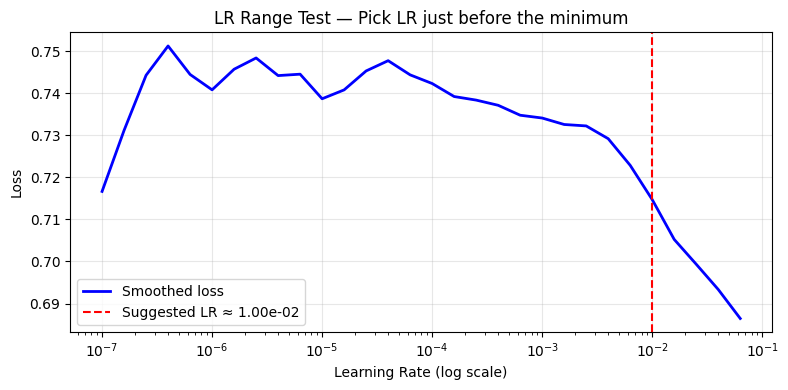

[LR-FIND] Suggested max_lr : 1.00e-02
[LR-FIND] PHASE1_LR set to : 1.00e-03


In [11]:
# ═══════════════════════════════════════════════════════════
# Cell 11 · LR Range Test (OPTIONAL in FAST MODE)
# ───────────────────────────────────────────────────────────
# In FAST_MODE: Skip this, use default LR (saves 5 min)
# Normal mode: Run 30 iterations to find optimal LR
# ═══════════════════════════════════════════════════════════

if FAST_MODE:
    print("[LR-FIND] ⚡ FAST MODE: Skipping LR range test (using default LR)")
    print(f"[LR-FIND] PHASE1_LR = {PHASE1_LR:.2e}  (ResNet50 standard)")
    PHASE1_LR = 3e-4  # Safe default for ResNet50 head fine-tune
else:
    print("[LR-FIND] Running LR range test (30 iter, ~2-3 min) …")

    _lrf_model = build_model(freeze_backbone=True).train()
    _lrf_opt   = optim.SGD(
        filter(lambda p: p.requires_grad, _lrf_model.parameters()),
        lr=1e-7, momentum=0.9)
    _lrf_crit  = nn.BCEWithLogitsLoss()

    NUM_ITER   = min(30, len(train_loader))
    LR_START   = 1e-7
    LR_END     = 1e-1
    LR_MULT    = (LR_END / LR_START) ** (1.0 / NUM_ITER)

    lrs, losses, smoothed = [], [], []
    best_loss = float('inf')
    avg_loss  = 0.0
    beta      = 0.98

    loader_iter = iter(train_loader)
    for i in range(NUM_ITER):
        try: imgs_b, lbl_b = next(loader_iter)
        except StopIteration: break

        imgs_b = imgs_b.to(device)
        lbl_b  = lbl_b.float().unsqueeze(1).to(device)

        _lrf_opt.zero_grad(set_to_none=True)
        loss = _lrf_crit(_lrf_model(imgs_b), lbl_b)
        loss.backward()
        _lrf_opt.step()

        raw = loss.item()
        avg_loss = beta*avg_loss + (1-beta)*raw
        smooth   = avg_loss / (1 - beta**(i+1))

        cur_lr = _lrf_opt.param_groups[0]['lr']
        lrs.append(cur_lr)
        losses.append(raw)
        smoothed.append(smooth)

        if smooth < best_loss: best_loss = smooth
        if smooth > 4 * best_loss: 
            break

        for pg in _lrf_opt.param_groups: pg['lr'] *= LR_MULT

    if len(smoothed) > 3:
        grads    = np.gradient(smoothed)
        best_idx = int(np.argmin(grads))
        suggested_lr = lrs[best_idx]
    else:
        suggested_lr = 1e-3

    fig, ax = plt.subplots(figsize=(8,4))
    ax.plot(lrs, smoothed, 'b-', lw=2, label='Smoothed loss')
    ax.axvline(suggested_lr, color='red', ls='--',
               label=f'Suggested LR ≈ {suggested_lr:.2e}')
    ax.set_xscale('log')
    ax.set_xlabel('Learning Rate (log scale)')
    ax.set_ylabel('Loss')
    ax.set_title('LR Range Test — Pick LR just before the minimum')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/lr_finder.png', dpi=120, bbox_inches='tight')
    plt.show()

    PHASE1_LR = suggested_lr / 10.0
    print(f"[LR-FIND] Suggested max_lr : {suggested_lr:.2e}")
    print(f"[LR-FIND] PHASE1_LR set to : {PHASE1_LR:.2e}")

    del _lrf_model, _lrf_opt
    torch.cuda.empty_cache() if torch.cuda.is_available() else None


In [12]:
# ═══════════════════════════════════════════════════════════
# Cell 12 · Loss, scaler, checkpoint utils, train/eval loops
# ═══════════════════════════════════════════════════════════

# Label smoothing: slightly softens targets (0→0.05, 1→0.95)
# Prevents overconfident wrong predictions and improves calibration
class SmoothBCELoss(nn.Module):
    def __init__(self, smoothing=0.05):
        super().__init__()
        self.s = smoothing
    def forward(self, logits, targets):
        t = targets * (1 - self.s) + 0.5 * self.s
        return F.binary_cross_entropy_with_logits(logits, t)

criterion = SmoothBCELoss(LABEL_SMOOTHING)
scaler    = torch.amp.GradScaler('cuda', enabled=USE_AMP)

# ── Checkpoint helpers ────────────────────────────────────
def save_ckpt(model, path):
    m = model.module if isinstance(model, nn.DataParallel) else model
    torch.save(m.state_dict(), path)

def load_ckpt(model, path):
    m = model.module if isinstance(model, nn.DataParallel) else model
    m.load_state_dict(torch.load(path, map_location='cpu'))
    model.to(device)
    return model

# ── Train loop ────────────────────────────────────────────
def train_epoch(model, loader, optimizer, scheduler=None, sched_per_batch=False):
    model.train()
    tot_loss = correct = total = 0
    for imgs, lbl in tqdm(loader, desc='  train', leave=False):
        imgs = imgs.to(device, non_blocking=True)
        lbl  = lbl.float().unsqueeze(1).to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if USE_AMP:
            with torch.amp.autocast('cuda'):
                out  = model(imgs)
                loss = criterion(out, lbl)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
        else:
            out  = model(imgs)
            loss = criterion(out, lbl)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
        if sched_per_batch and scheduler: scheduler.step()
        bs = imgs.size(0)
        tot_loss += loss.detach().item() * bs
        correct  += ((out.detach()>0).float()==lbl).sum().item()
        total    += bs
    return tot_loss/total, correct/total

# ── Eval loop ─────────────────────────────────────────────
@torch.no_grad()
def eval_epoch(model, loader, desc='val'):
    model.eval()
    tot_loss = correct = total = 0
    probs_all, labels_all = [], []
    for imgs, lbl in tqdm(loader, desc=f'  {desc}', leave=False):
        imgs = imgs.to(device, non_blocking=True)
        lbl  = lbl.float().unsqueeze(1).to(device, non_blocking=True)
        if USE_AMP:
            with torch.amp.autocast('cuda'): out = model(imgs)
        else: out = model(imgs)
        loss = F.binary_cross_entropy_with_logits(out, lbl)  # raw loss for monitoring
        p    = torch.sigmoid(out)
        bs   = imgs.size(0)
        tot_loss += loss.item()*bs
        correct  += ((out>0).float()==lbl).sum().item()
        total    += bs
        probs_all.extend(p.cpu().squeeze(1).tolist())
        labels_all.extend(lbl.cpu().squeeze(1).tolist())
    auc = roc_auc_score(labels_all, probs_all) if len(set(labels_all))>1 else 0.5
    return tot_loss/total, correct/total, auc

print("[UTILS] Label smoothing criterion, GradScaler, train/eval loops ready")
print(f"[UTILS] Label smoothing = {LABEL_SMOOTHING}  GradClip = {GRAD_CLIP}")


[UTILS] Label smoothing criterion, GradScaler, train/eval loops ready
[UTILS] Label smoothing = 0.05  GradClip = 1.0


In [13]:
# ═══════════════════════════════════════════════════════════
# Cell 13 · Phase 1 — Head only, single GPU
# ───────────────────────────────────────────────────────────
# Single GPU: DataParallel overhead > benefit for a tiny head.
# OneCycleLR: warmup then cosine decay — fastest convergence.
# Early stopping: stops when val loss doesn't improve by
#   ES_MIN_DELTA for ES_PATIENCE_P1 consecutive epochs.
# ═══════════════════════════════════════════════════════════
for p in model.parameters(): p.requires_grad = False
for p in model.fc.parameters(): p.requires_grad = True

trn_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[P1] Trainable (head only): {trn_p:,}")

opt_p1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_LR, weight_decay=WEIGHT_DECAY)
sched_p1 = optim.lr_scheduler.OneCycleLR(
    opt_p1, max_lr=PHASE1_LR,
    steps_per_epoch=len(train_loader),
    epochs=PHASE1_EPOCHS, pct_start=0.15, anneal_strategy='cos')

history = {k:[] for k in ['tr_loss','tr_acc','va_loss','va_acc','va_auc']}
best_val_loss = float('inf')
best_val_acc  = 0.0
patience_ctr  = 0

print("="*62)
print("  PHASE 1 — Head only (backbone frozen)")
print(f"  OneCycleLR max_lr={PHASE1_LR:.2e}  patience={ES_PATIENCE_P1}")
print("="*62)

for ep in range(1, PHASE1_EPOCHS+1):
    t0 = time.time()
    # Per-batch scheduler step (OneCycleLR)
    tr_loss, tr_acc          = train_epoch(model, train_loader, opt_p1,
                                            sched_p1, sched_per_batch=True)
    va_loss, va_acc, va_auc  = eval_epoch(model, val_loader)

    for k,v in zip(['tr_loss','tr_acc','va_loss','va_acc','va_auc'],
                   [tr_loss,tr_acc,va_loss,va_acc,va_auc]):
        history[k].append(v)

    improved = va_loss < best_val_loss - ES_MIN_DELTA
    saved = ''
    if improved:
        best_val_loss = va_loss; best_val_acc = va_acc
        save_ckpt(model, BEST_CKPT)
        patience_ctr = 0; saved = '  ✓'
    else:
        patience_ctr += 1

    gap = va_acc - tr_acc
    fit = '  [overfit]' if gap<-0.05 else ('  [underfit]' if gap>0.05 else '')
    lr_now = opt_p1.param_groups[0]['lr']
    print(f"[P1 {ep:02d}/{PHASE1_EPOCHS}] "
          f"tr={tr_acc:.4f}/{tr_loss:.4f}  "
          f"va={va_acc:.4f}/{va_loss:.4f}  "
          f"AUC={va_auc:.4f}  "
          f"lr={lr_now:.1e}  {time.time()-t0:.0f}s{saved}{fit}")

    if patience_ctr >= ES_PATIENCE_P1:
        print(f"[P1] Early stop — no improvement for {ES_PATIENCE_P1} epochs")
        break

p1_ep = ep
print(f"\n[P1] Done — best val loss={best_val_loss:.4f}  acc={best_val_acc:.4f}")


[P1] Trainable (head only): 1,054,721
  PHASE 1 — Head only (backbone frozen)
  OneCycleLR max_lr=1.00e-03  patience=3


  val:  35%|███▌      | 20/57 [01:44<01:45,  2.85s/it]

[WARN] Corrupted: 8022.jpg


[P1 01/5] tr=0.8105/0.4447  va=0.8743/0.3080  AUC=0.9458  lr=9.9e-04  1938s  ✓  [underfit]


[P1 02/5] tr=0.8628/0.3719  va=0.8854/0.2854  AUC=0.9561  lr=8.0e-04  1958s  ✓


[P1 03/5] tr=0.8761/0.3487  va=0.9012/0.2623  AUC=0.9634  lr=4.5e-04  2103s  ✓


[P1 04/5] tr=0.8905/0.3271  va=0.9004/0.2549  AUC=0.9659  lr=1.3e-04  1986s  ✓


[P1 05/5] tr=0.8977/0.3176  va=0.9064/0.2482  AUC=0.9669  lr=5.3e-09  1946s  ✓

[P1] Done — best val loss=0.2482  acc=0.9064


In [14]:
# ═══════════════════════════════════════════════════════════
# Cell 14 · Phase 2 — Full fine-tune, DataParallel
# ───────────────────────────────────────────────────────────
# Load best Phase-1 checkpoint before unfreezing.
# Differential LR: backbone = PHASE2_LR/10 (avoids forgetting)
#                  head     = PHASE2_LR
# DataParallel: worth it now — full backbone compute >> DP overhead.
# OneCycleLR: fresh cycle for the whole unfrozen model.
# ═══════════════════════════════════════════════════════════
load_ckpt(model, BEST_CKPT)
for p in model.parameters(): p.requires_grad = True  # unfreeze all

if n_gpus > 1:
    model_p2 = nn.DataParallel(model).to(device)
    print(f"[P2] DataParallel across {n_gpus} GPUs")
else:
    model_p2 = model
    print("[P2] Single GPU")

core     = model_p2.module if isinstance(model_p2, nn.DataParallel) else model_p2
bb_params = [p for n,p in core.named_parameters() if not n.startswith('fc')]
hd_params = [p for n,p in core.named_parameters() if n.startswith('fc')]

opt_p2 = optim.AdamW([
    {'params': bb_params, 'lr': PHASE2_LR/10, 'weight_decay': WEIGHT_DECAY},
    {'params': hd_params, 'lr': PHASE2_LR,    'weight_decay': WEIGHT_DECAY},
])
sched_p2 = optim.lr_scheduler.OneCycleLR(
    opt_p2, max_lr=[PHASE2_LR/10, PHASE2_LR],
    steps_per_epoch=len(train_loader), epochs=PHASE2_EPOCHS,
    pct_start=0.1, anneal_strategy='cos', final_div_factor=1e3)

patience_ctr = 0

print("="*62)
print(f"  PHASE 2 — Full fine-tune")
print(f"  backbone lr={PHASE2_LR/10:.1e}  head lr={PHASE2_LR:.1e}")
print(f"  patience={ES_PATIENCE_P2}  min_delta={ES_MIN_DELTA}")
print("="*62)

for ep in range(1, PHASE2_EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_acc         = train_epoch(model_p2, train_loader, opt_p2,
                                           sched_p2, sched_per_batch=True)
    va_loss, va_acc, va_auc = eval_epoch(model_p2, val_loader)

    for k,v in zip(['tr_loss','tr_acc','va_loss','va_acc','va_auc'],
                   [tr_loss,tr_acc,va_loss,va_acc,va_auc]):
        history[k].append(v)

    improved = va_loss < best_val_loss - ES_MIN_DELTA
    saved = ''
    if improved:
        best_val_loss = va_loss; best_val_acc = va_acc
        save_ckpt(model_p2, BEST_CKPT)
        patience_ctr = 0; saved = '  ✓'
    else:
        patience_ctr += 1

    gap = va_acc - tr_acc
    fit = '  [overfit]' if gap<-0.06 else ('  [underfit]' if gap>0.06 else '')
    lr_bb = opt_p2.param_groups[0]['lr']
    lr_hd = opt_p2.param_groups[1]['lr']
    print(f"[P2 {ep:02d}/{PHASE2_EPOCHS}] "
          f"tr={tr_acc:.4f}/{tr_loss:.4f}  "
          f"va={va_acc:.4f}/{va_loss:.4f}  "
          f"AUC={va_auc:.4f}  "
          f"lr_bb={lr_bb:.1e}  {time.time()-t0:.0f}s{saved}{fit}")

    if patience_ctr >= ES_PATIENCE_P2:
        print(f"[P2] Early stop — no improvement for {ES_PATIENCE_P2} epochs")
        break

p2_ep = ep
print(f"\n[P2] Done — best val loss={best_val_loss:.4f}  acc={best_val_acc:.4f}")


[P2] DataParallel across 2 GPUs
  PHASE 2 — Full fine-tune
  backbone lr=5.0e-06  head lr=5.0e-05
  patience=4  min_delta=0.0001


[P2 01/5] tr=0.8935/0.3226  va=0.9107/0.2370  AUC=0.9703  lr_bb=4.8e-06  2198s  ✓


[P2 02/5] tr=0.9068/0.3025  va=0.9153/0.2240  AUC=0.9737  lr_bb=3.7e-06  2317s  ✓


[P2 03/5] tr=0.9113/0.2929  va=0.9225/0.2151  AUC=0.9759  lr_bb=2.1e-06  2248s  ✓


[P2 04/5] tr=0.9187/0.2820  va=0.9206/0.2137  AUC=0.9763  lr_bb=5.8e-07  2146s  ✓


[P2 05/5] tr=0.9210/0.2773  va=0.9233/0.2117  AUC=0.9762  lr_bb=2.1e-10  2138s  ✓

[P2] Done — best val loss=0.2117  acc=0.9233


In [15]:
import shutil
import os

OUTPUT_DIR = "/kaggle/working/output"
PERSIST_DIR = "/kaggle/output"  # ← Persistent, downloadable

os.makedirs(PERSIST_DIR, exist_ok=True)

print(f"[SAVE] Copying results to Kaggle output …")
for fname in os.listdir(OUTPUT_DIR):
    src = os.path.join(OUTPUT_DIR, fname)
    dst = os.path.join(PERSIST_DIR, fname)
    if os.path.isfile(src):
        shutil.copy2(src, dst)
        size = os.path.getsize(dst) / (1024**2)
        print(f"  ✓ {fname:<45} {size:.2f} MB")

print(f"\n✅ All files saved to /kaggle/output")
print(f"   → Download from notebook 'Data' tab")

[SAVE] Copying results to Kaggle output …
  ✓ lr_finder.png                                 0.05 MB
  ✓ best.pth                                      94.01 MB

✅ All files saved to /kaggle/output
   → Download from notebook 'Data' tab


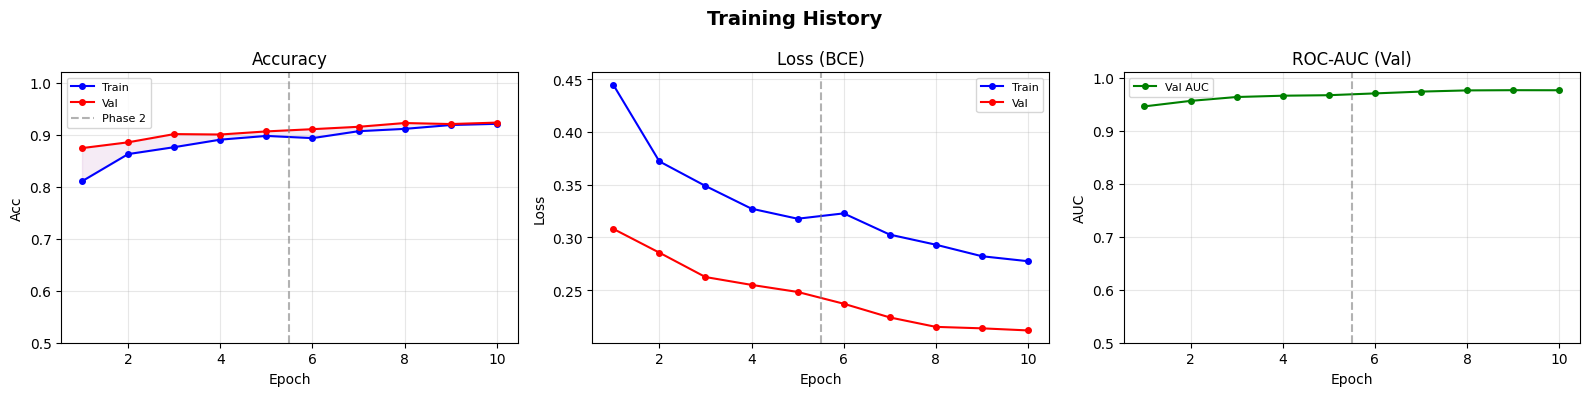

[FIT] Final train acc : 0.9210
[FIT] Final val acc   : 0.9233
[FIT] Gap (val-train) : +0.0024
[FIT] ✓ Well-fitted (gap < 3%)


In [16]:




# ═══════════════════════════════════════════════════════════
# Cell 15 · Training curves + fit assessment 
# ═══════════════════════════════════════════════════════════
n_ep     = len(history['tr_loss']) 
ep_range = range(1, n_ep+1)
p1_end   = p1_ep   # epoch where Phase 1  end

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(ep_range, history['tr_acc'], 'b-o', ms=4, label='Train')
ax.plot(ep_range, history['va_acc'], 'r-o', ms=4, label='Val')
ax.fill_between(ep_range, history['tr_acc'], history['va_acc'],
                alpha=0.08, color='purple')
ax.axvline(p1_end+0.5, color='gray', ls='--', alpha=0.6, label='Phase 2')
ax.set(title='Accuracy', xlabel='Epoch', ylabel='Acc', ylim=(0.5,1.02))
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(ep_range, history['tr_loss'], 'b-o', ms=4, label='Train')
ax.plot(ep_range, history['va_loss'], 'r-o', ms=4, label='Val')
ax.axvline(p1_end+0.5, color='gray', ls='--', alpha=0.6)
ax.set(title='Loss (BCE)', xlabel='Epoch', ylabel='Loss')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(ep_range, history['va_auc'], 'g-o', ms=4, label='Val AUC')
ax.axvline(p1_end+0.5, color='gray', ls='--', alpha=0.6)
ax.set(title='ROC-AUC (Val)', xlabel='Epoch', ylabel='AUC', ylim=(0.5,1.01))
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fit assessment ─────────────────────────────────────────
gap = history['va_acc'][-1] - history['tr_acc'][-1]
print(f"[FIT] Final train acc : {history['tr_acc'][-1]:.4f}")
print(f"[FIT] Final val acc   : {history['va_acc'][-1]:.4f}")
print(f"[FIT] Gap (val-train) : {gap:+.4f}")
if abs(gap) < 0.03:
    print("[FIT] ✓ Well-fitted (gap < 3%)")
elif gap < -0.03:
    print("[FIT] ⚠ Possible overfit — consider more dropout or less data aug")
else:
    print("[FIT] ⚠ Possible underfit — model may need more epochs or larger LR")


In [17]:
# ═══════════════════════════════════════════════════════════
# Cell 16 · Standard test evaluation (threshold = 0.5) — FIXED
# ═══════════════════════════════════════════════════════════
print("[EVAL] Loading best checkpoint …")

# Load from saved checkpoint into a fresh model
eval_model = build_model(freeze_backbone=False)  # Fresh model
load_ckpt(eval_model, BEST_CKPT)
eval_model.eval()

all_preds, all_labels_t, all_probs = [], [], []

with torch.no_grad():
    for imgs, lbl in tqdm(test_loader, desc='  test', leave=False):
        imgs = imgs.to(device, non_blocking=True)
        if USE_AMP:
            with torch.amp.autocast('cuda'): out = eval_model(imgs)
        else: out = eval_model(imgs)
        p    = torch.sigmoid(out).cpu().squeeze(1)
        pred = (p > 0.5).int()
        all_probs.extend(p.tolist())
        all_preds.extend(pred.tolist())
        all_labels_t.extend(lbl.tolist())

test_auc = roc_auc_score(all_labels_t, all_probs)
test_acc = sum(p==l for p,l in zip(all_preds,all_labels_t))/len(all_labels_t)

print("\n" + "="*60)
print(f"{'TEST RESULTS  (threshold=0.5)':^60}")
print("="*60)
print(classification_report(all_labels_t, all_preds,
                             target_names=ds_train.classes, digits=4))
print(f"  ROC-AUC  : {test_auc:.4f}")
print(f"  Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print("="*60) 

[EVAL] Loading best checkpoint …


  test:  93%|█████████▎| 87/94 [06:35<00:31,  4.55s/it]

[WARN] Corrupted: 5197.jpg
[WARN] Corrupted: 5325.jpg


  test:  98%|█████████▊| 92/94 [08:03<00:18,  9.18s/it]

[WARN] Corrupted: 5879.jpg



               TEST RESULTS  (threshold=0.5)                
              precision    recall  f1-score   support

        fake     0.9244    0.9255    0.9250      6000
        real     0.9254    0.9243    0.9249      6000

    accuracy                         0.9249     12000
   macro avg     0.9249    0.9249    0.9249     12000
weighted avg     0.9249    0.9249    0.9249     12000

  ROC-AUC  : 0.9787
  Accuracy : 0.9249  (92.49%)


In [18]:
# ═══════════════════════════════════════════════════════════
# Cell 17 · Test-Time Augmentation (TTA)
# ───────────────────────────────────────────────────────────
# WHY: Instead of a single forward pass per image, we run
# 5 slightly-different crops/flips and average the probabilities.
# Cost: 5× inference time.  Gain: typically +0.5–1% accuracy
# and better calibration — completely free improvement.
# ═══════════════════════════════════════════════════════════
print("[TTA] Running 5-view TTA on test set …")

eval_model.eval()
tta_probs_all  = None   # will accumulate sum of probs
tta_labels_all = []

for t_idx, tfm in enumerate(tta_transforms):
    ds_tta = SafeImageFolder(str(Path(LOCAL_DATA)/'test'), transform=tfm)
    # Fix random seed for reproducible TTA crops
    torch.manual_seed(SEED + t_idx)
    ld_tta = DataLoader(ds_tta, **{**loader_kw, 'shuffle': False})

    probs_this = []
    with torch.no_grad():
        for imgs, lbl in tqdm(ld_tta, desc=f'  TTA view {t_idx+1}/5', leave=False):
            imgs = imgs.to(device, non_blocking=True)
            if USE_AMP:
                with torch.amp.autocast('cuda'): out = eval_model(imgs)
            else: out = eval_model(imgs)
            p = torch.sigmoid(out).cpu().squeeze(1)
            probs_this.extend(p.tolist())
            if t_idx == 0: tta_labels_all.extend(lbl.tolist())

    arr = np.array(probs_this)
    tta_probs_all = arr if tta_probs_all is None else tta_probs_all + arr

tta_probs_avg = tta_probs_all / len(tta_transforms)
tta_preds     = (tta_probs_avg > 0.5).astype(int)
tta_auc       = roc_auc_score(tta_labels_all, tta_probs_avg)
tta_acc       = (tta_preds == np.array(tta_labels_all)).mean()

print(f"\n[TTA] Accuracy : {tta_acc:.4f}  ({tta_acc*100:.2f}%)")
print(f"[TTA] AUC      : {tta_auc:.4f}")
print(f"[TTA] vs single-pass: acc Δ={tta_acc-test_acc:+.4f}  AUC Δ={tta_auc-test_auc:+.4f}")


[TTA] Running 5-view TTA on test set …


  TTA view 1/5:  93%|█████████▎| 87/94 [05:54<00:32,  4.68s/it]

[WARN] Corrupted: 5197.jpg
[WARN] Corrupted: 5325.jpg


  TTA view 1/5:  98%|█████████▊| 92/94 [07:15<00:17,  8.69s/it]

[WARN] Corrupted: 5879.jpg


...

  TTA view 5/5:  93%|█████████▎| 87/94 [05:44<00:31,  4.45s/it]

[WARN] Corrupted: 5197.jpg
[WARN] Corrupted: 5325.jpg


  TTA view 5/5:  98%|█████████▊| 92/94 [07:08<00:17,  8.95s/it]

[WARN] Corrupted: 5879.jpg



[TTA] Accuracy : 0.9259  (92.59%)
[TTA] AUC      : 0.9798
[TTA] vs single-pass: acc Δ=+0.0010  AUC Δ=+0.0011


[THRESH] Optimal threshold (Youden J) : 0.4773
[THRESH] Accuracy @ optimal threshold  : 0.9275  vs 0.5-thresh: 0.9259


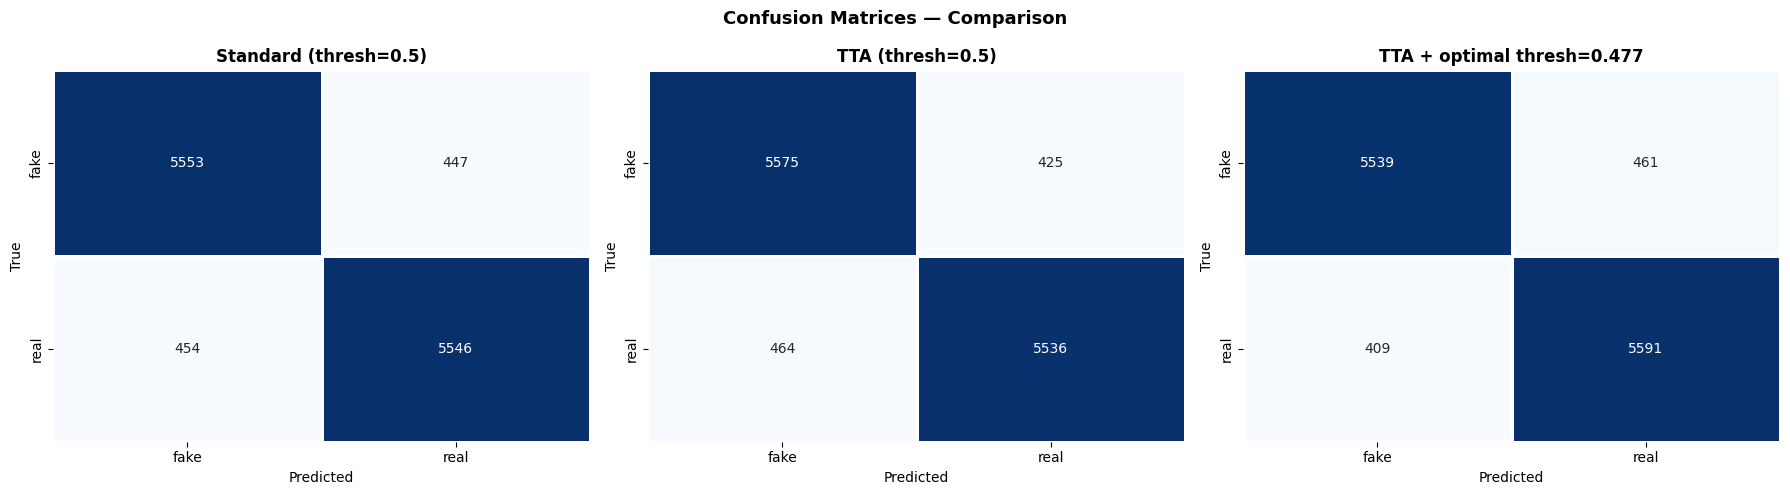

In [19]:
# ═══════════════════════════════════════════════════════════
# Cell 18 · Optimal threshold + confusion matrices
# ─────────────────────────────────────────────────────────── 
# WHY: Hard-coding threshold=0.5 is rarely optimal.
# Youden's J statistic finds the threshold that maximises
# (sensitivity + specificity - 1), balancing both error types.
# ═══════════════════════════════════════════════════════════
        
# Use TTA probs for final reporting
fpr, tpr, thresholds = roc_curve(tta_labels_all, tta_probs_avg)
j_scores    = tpr - fpr
best_idx    = int(np.argmax(j_scores))
best_thresh = float(thresholds[best_idx])

tta_preds_opt = (tta_probs_avg > best_thresh).astype(int)
opt_acc = (tta_preds_opt == np.array(tta_labels_all)).mean()
print(f"[THRESH] Optimal threshold (Youden J) : {best_thresh:.4f}")
print(f"[THRESH] Accuracy @ optimal threshold  : {opt_acc:.4f}  vs 0.5-thresh: {tta_acc:.4f}")

# ── Confusion matrices (0.5 vs optimal) ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, preds, title in [
    (axes[0], np.array(all_preds),        'Standard (thresh=0.5)'),
    (axes[1], np.array(tta_preds),        f'TTA (thresh=0.5)'),
    (axes[2], np.array(tta_preds_opt),    f'TTA + optimal thresh={best_thresh:.3f}'),
]:
    cm = confusion_matrix(tta_labels_all if 'TTA' in title else all_labels_t, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=ds_train.classes,
                yticklabels=ds_train.classes,
                linewidths=1, linecolor='white', cbar=False)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


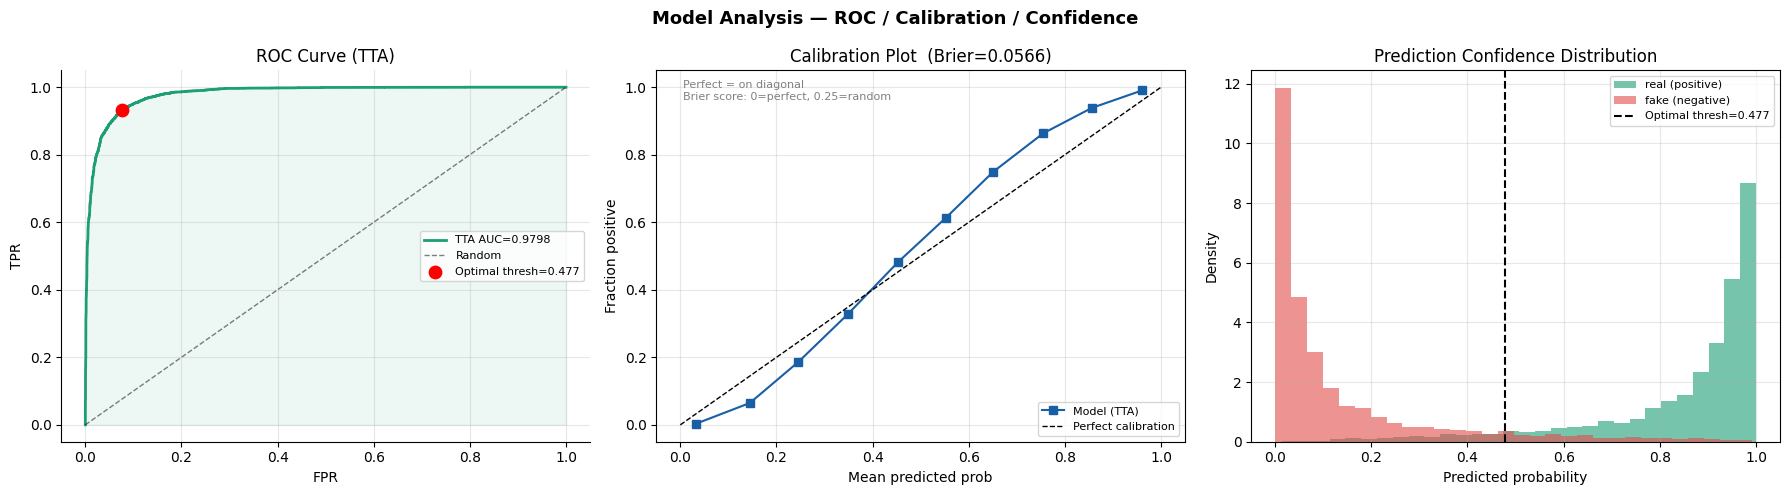

[CALIB] Brier score : 0.0566  (0=perfect  0.25=random)
[CALIB] Well-calibrated: ✓ YES


In [20]:
# ═══════════════════════════════════════════════════════════
# Cell 19 · ROC curve + Calibration plot + Error analysis
# ───────────────────────────────────────────────────────────
# Calibration: does P(model)=0.7 mean 70% of those images
# actually belong to the positive class?
# A perfectly calibrated model's calibration curve sits on
# the diagonal.  Tells you whether you can trust the score.
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── ROC curve ─────────────────────────────────────────────
ax = axes[0]
ax.plot(fpr, tpr, color='#1D9E75', lw=2, label=f'TTA AUC={tta_auc:.4f}')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Random')
ax.fill_between(fpr, tpr, alpha=0.08, color='#1D9E75')
ax.scatter(fpr[best_idx], tpr[best_idx], s=80, color='red', zorder=5,
           label=f'Optimal thresh={best_thresh:.3f}')
ax.set(title='ROC Curve (TTA)',xlabel='FPR',ylabel='TPR')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# ── Calibration plot ──────────────────────────────────────
ax = axes[1]
n_bins = 10
frac_pos, mean_pred = calibration_curve(tta_labels_all, tta_probs_avg, n_bins=n_bins)
ax.plot(mean_pred, frac_pos, 's-', color='#185FA5', label='Model (TTA)')
ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect calibration')
ax.fill_between([0,1],[0,1],[0,1],alpha=0.05,color='gray')
brier = brier_score_loss(tta_labels_all, tta_probs_avg)
ax.set(title=f'Calibration Plot  (Brier={brier:.4f})',
       xlabel='Mean predicted prob', ylabel='Fraction positive')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.text(0.05,0.92,
        'Perfect = on diagonal\nBrier score: 0=perfect, 0.25=random',
        transform=ax.transAxes, fontsize=8, color='gray')

# ── Confidence distribution ────────────────────────────────
ax = axes[2]
probs_arr  = np.array(tta_probs_avg)
labels_arr = np.array(tta_labels_all)
ax.hist(probs_arr[labels_arr==1], bins=30, alpha=0.6,
        color='#1D9E75', label=f'{ds_train.classes[1]} (positive)', density=True)
ax.hist(probs_arr[labels_arr==0], bins=30, alpha=0.6,
        color='#E24B4A', label=f'{ds_train.classes[0]} (negative)', density=True)
ax.axvline(best_thresh, color='black', ls='--',
           label=f'Optimal thresh={best_thresh:.3f}')
ax.set(title='Prediction Confidence Distribution',
       xlabel='Predicted probability', ylabel='Density')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Model Analysis — ROC / Calibration / Confidence',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"[CALIB] Brier score : {brier:.4f}  (0=perfect  0.25=random)")
print(f"[CALIB] Well-calibrated: {'✓ YES' if brier < 0.10 else '⚠ check calibration plot'}")


[ERRORS] Finding high-confidence mistakes …


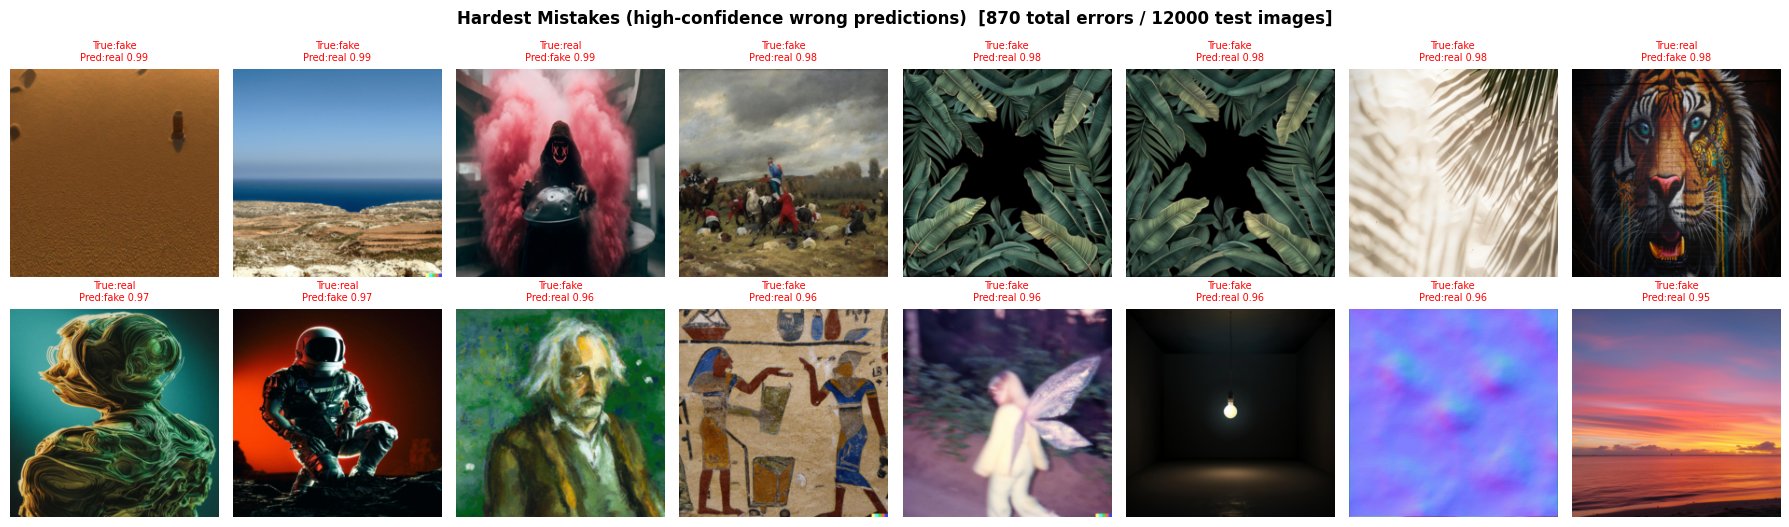

[ERRORS] Total errors   : 870 / 12000 (7.25%)
[ERRORS] Error plot saved


In [21]:
# ═══════════════════════════════════════════════════════════
# Cell 20 · Error analysis — show hardest mistakes
# ───────────────────────────────────────────────────────────
# WHY: Looking at which images the model gets most wrong
# tells you what the model is actually learning (or not).
# High-confidence wrong predictions = systematic failures.
# ═══════════════════════════════════════════════════════════
print("[ERRORS] Finding high-confidence mistakes …")

probs_arr  = np.array(tta_probs_avg)
labels_arr = np.array(tta_labels_all)
preds_arr  = (probs_arr > best_thresh).astype(int)

wrong_idx   = np.where(preds_arr != labels_arr)[0]
confidences = np.where(preds_arr==1, probs_arr, 1-probs_arr)  # confidence in wrong pred
hardest_idx = wrong_idx[np.argsort(-confidences[wrong_idx])][:16]

def denorm(t):
    m = torch.tensor(MEAN).view(3,1,1)
    s = torch.tensor(STD).view(3,1,1)
    return torch.clamp(t*s+m,0,1)

fig, axes = plt.subplots(2, 8, figsize=(18, 5.5))
axes = axes.flat

shown = 0
for idx in hardest_idx:
    if shown >= 16: break
    path, true_lbl = ds_test.samples[idx]
    try:
        img_pil = Image.open(path).convert('RGB')
        img_t   = eval_transform(img_pil)
        img_np  = denorm(img_t).permute(1,2,0).numpy()
        pred_lbl = int(preds_arr[idx])
        conf     = confidences[idx]
        axes[shown].imshow(img_np)
        axes[shown].set_title(
            f"True:{ds_train.classes[true_lbl]}\nPred:{ds_train.classes[pred_lbl]} {conf:.2f}",
            fontsize=7, color='red')
        axes[shown].axis('off')
        shown += 1
    except: pass

for ax in list(axes)[shown:]: ax.axis('off')
plt.suptitle(f'Hardest Mistakes (high-confidence wrong predictions)  '
             f'[{len(wrong_idx)} total errors / {len(labels_arr)} test images]',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"[ERRORS] Total errors   : {len(wrong_idx)} / {len(labels_arr)} ({len(wrong_idx)/len(labels_arr)*100:.2f}%)")
print(f"[ERRORS] Error plot saved")


In [22]:
# ═══════════════════════════════════════════════════════════
# Cell 21 · Model export (ONNX + TorchScript + .ptl) — FIXED
# ═══════════════════════════════════════════════════════════
from torch.utils.mobile_optimizer import optimize_for_mobile

# Load best checkpoint into fresh model
export_model = build_model(freeze_backbone=False)
load_ckpt(export_model, BEST_CKPT)
export_model.eval().cpu()

dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

# ── TorchScript ──────────────────────────────────────────
try:
    traced  = torch.jit.trace(export_model, dummy)
    ts_path = f'{OUTPUT_DIR}/resnet50.pt'
    traced.save(ts_path)
    print(f"[EXPORT] TorchScript → {ts_path}  ({os.path.getsize(ts_path)/1024**2:.1f} MB)")
except Exception as e:
    print(f"[EXPORT] TorchScript failed: {e}"); traced = None

# ── ONNX ─────────────────────────────────────────────────
try:
    onnx_path = f'{OUTPUT_DIR}/resnet50.onnx'
    torch.onnx.export(export_model, dummy, onnx_path,
                      input_names=['input'], output_names=['logit'],
                      dynamic_axes={'input':{0:'batch'},'logit':{0:'batch'}},
                      opset_version=17, do_constant_folding=True)
    print(f"[EXPORT] ONNX         → {onnx_path}  ({os.path.getsize(onnx_path)/1024**2:.1f} MB)")
except Exception as e:
    print(f"[EXPORT] ONNX failed: {e}")

# ── Mobile .ptl ──────────────────────────────────────────
if traced is not None:
    try:
        opt   = optimize_for_mobile(traced)
        ppath = f'{OUTPUT_DIR}/resnet50_mobile.ptl'
        opt._save_for_lite_interpreter(ppath)
        print(f"[EXPORT] Mobile .ptl  → {ppath}  ({os.path.getsize(ppath)/1024**2:.1f} MB)")
    except Exception as e:
        print(f"[EXPORT] .ptl failed: {e}")

# ── Save metadata ────────────────────────────────────────
import json
meta = {
    'optimal_threshold': round(best_thresh, 6),
    'tta_accuracy': round(float(tta_acc), 6),
    'tta_auc': round(float(tta_auc), 6),
    'brier_score': round(float(brier), 6),
    'classes': ds_train.classes,
    'img_size': IMG_SIZE,
    'mean': MEAN, 
    'std': STD,
}
with open(f'{OUTPUT_DIR}/model_meta.json','w') as f:
    json.dump(meta, f, indent=2)

print(f"[EXPORT] Metadata     → {OUTPUT_DIR}/model_meta.json")
print(f"[EXPORT] Optimal threshold saved: {best_thresh:.6f}  ← use this at inference!")

[EXPORT] TorchScript → /kaggle/working/output/resnet50.pt  (94.3 MB)
[EXPORT] ONNX failed: No module named 'onnxscript'
[EXPORT] Mobile .ptl  → /kaggle/working/output/resnet50_mobile.ptl  (93.6 MB)
[EXPORT] Metadata     → /kaggle/working/output/model_meta.json
[EXPORT] Optimal threshold saved: 0.477344  ← use this at inference!


In [23]:
# ═══════════════════════════════════════════════════════════
# Cell 22 · Final summary
# ═══════════════════════════════════════════════════════════
print("\n" + "="*62)
print(f"  FINAL SUMMARY")
print("="*62)
print(f"  Model          : ResNet50 (ImageNet V2 pretrained)")
print(f"  Total epochs   : {len(history['tr_loss'])}  "
      f"(Phase1={p1_ep}  Phase2={len(history['tr_loss'])-p1_ep})")
print(f"  Label smoothing: {LABEL_SMOOTHING}")
print(f"  Grad clipping  : {GRAD_CLIP}")
print()
print(f"  ── Validation (best checkpoint) ──")
print(f"  Best val loss  : {best_val_loss:.4f}")
print(f"  Best val acc   : {best_val_acc:.4f}  ({best_val_acc*100:.2f}%)")
print()
print(f"  ── Test set (single-pass, thresh=0.5) ──")
print(f"  Accuracy       : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  AUC            : {test_auc:.4f}")
print()
print(f"  ── Test set (5-view TTA, optimal thresh) ──")
print(f"  Accuracy       : {opt_acc:.4f}  ({opt_acc*100:.2f}%)  ← use this")
print(f"  AUC            : {tta_auc:.4f}")
print(f"  Optimal thresh : {best_thresh:.4f}")
print(f"  Brier score    : {brier:.4f}")
print()
print(f"  Fit check      : gap={history['va_acc'][-1]-history['tr_acc'][-1]:+.4f}  "
      f"{'✓ well-fitted' if abs(history['va_acc'][-1]-history['tr_acc'][-1])<0.03 else '⚠ check curves'}")
print()
print("  Output files:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fp = f'{OUTPUT_DIR}/{fname}'
    print(f"    {fname:<45} {os.path.getsize(fp)/1024**2:.1f} MB")
print("="*62)



  FINAL SUMMARY
  Model          : ResNet50 (ImageNet V2 pretrained)
  Total epochs   : 10  (Phase1=5  Phase2=5)
  Label smoothing: 0.05
  Grad clipping  : 1.0

  ── Validation (best checkpoint) ──
  Best val loss  : 0.2117
  Best val acc   : 0.9233  (92.33%)

  ── Test set (single-pass, thresh=0.5) ──
  Accuracy       : 0.9249  (92.49%)
  AUC            : 0.9787

  ── Test set (5-view TTA, optimal thresh) ──
  Accuracy       : 0.9275  (92.75%)  ← use this
  AUC            : 0.9798
  Optimal thresh : 0.4773
  Brier score    : 0.0566

  Fit check      : gap=+0.0024  ✓ well-fitted

  Output files:
    best.pth                                      94.0 MB
    confusion_matrices.png                        0.0 MB
    error_analysis.png                            2.2 MB
    lr_finder.png                                 0.0 MB
    model_analysis.png                            0.1 MB
    model_meta.json                               0.0 MB
    resnet50.pt                                   94.

In [24]:
# Copy everything to persistent Kaggle output
import shutil
import os

SRC = "/kaggle/working/output"
DST = "/kaggle/output"

os.makedirs(DST, exist_ok=True)

print(f"[COPY] Moving all results to {DST} ...\n")
for fname in sorted(os.listdir(SRC)):
    src_path = os.path.join(SRC, fname)
    dst_path = os.path.join(DST, fname)
    if os.path.isfile(src_path):
        shutil.copy2(src_path, dst_path)
        size = os.path.getsize(dst_path) / (1024**2)
        print(f"✓ {fname:<40} {size:>6.2f} MB")

print(f"\n✅ All {len(os.listdir(DST))} files ready for download!")

[COPY] Moving all results to /kaggle/output ...

✓ best.pth                                  94.01 MB
✓ confusion_matrices.png                     0.05 MB
✓ error_analysis.png                         2.17 MB
✓ lr_finder.png                              0.05 MB
✓ model_analysis.png                         0.14 MB
✓ model_meta.json                            0.00 MB
✓ resnet50.pt                               94.29 MB
✓ resnet50_mobile.ptl                       93.55 MB
✓ training_curves.png                        0.08 MB

✅ All 9 files ready for download!
